# Download the Dataset

In [1]:
from google.colab import files

files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"verma7903","key":"d8bae3ed16aec0daad007fbf38436ede"}'}

In [2]:
import os

os.makedirs('/root/.kaggle', exist_ok=True)

!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

In [3]:
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 157M/157M [00:06<00:00, 23.6MB/s]



In [4]:
!unzip -q brain-tumor-mri-dataset.zip -d /content/brain_tumor_dataset

In [5]:
!ls /content/brain_tumor_dataset

Testing  Training


# Check the Actual Structure

brain_tumor_dataset/
│
├── Training/
│   ├── glioma/
│   ├── meningioma/
│   ├── notumor/
│   └── pituitary/
│
└── Testing/
    ├── glioma/
    ├── meningioma/
    ├── notumor/
    └── pituitary/

In [6]:
import os

for root, dirs, files in os.walk('/content/brain_tumor_dataset'):
    print(root)
    if len(files) > 0:
        print("  Images:", len(files))

/content/brain_tumor_dataset
/content/brain_tumor_dataset/Testing
/content/brain_tumor_dataset/Testing/glioma
  Images: 400
/content/brain_tumor_dataset/Testing/pituitary
  Images: 400
/content/brain_tumor_dataset/Testing/meningioma
  Images: 400
/content/brain_tumor_dataset/Testing/notumor
  Images: 400
/content/brain_tumor_dataset/Training
/content/brain_tumor_dataset/Training/glioma
  Images: 1400
/content/brain_tumor_dataset/Training/pituitary
  Images: 1400
/content/brain_tumor_dataset/Training/meningioma
  Images: 1400
/content/brain_tumor_dataset/Training/notumor
  Images: 1400


# Define Paths

In [7]:
train_path = "/content/brain_tumor_dataset/Training"
test_path = "/content/brain_tumor_dataset/Testing"

In [8]:
print(os.listdir(train_path))

['glioma', 'pituitary', 'meningioma', 'notumor']


In [9]:
!ls /content/brain_tumor_dataset

Testing  Training


# 1. Dataset Exploration

# Import libraries

In [11]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define paths

In [12]:
train_path = "/content/brain_tumor_dataset/Training"
test_path = "/content/brain_tumor_dataset/Testing"

In [13]:
classes = os.listdir(train_path)

print("Classes:", classes)

Classes: ['glioma', 'pituitary', 'meningioma', 'notumor']


# Count images

In [14]:
train_counts = {}

for class_name in classes:
    class_path = os.path.join(train_path, class_name)
    train_counts[class_name] = len(os.listdir(class_path))

train_counts

{'glioma': 1400, 'pituitary': 1400, 'meningioma': 1400, 'notumor': 1400}

In [15]:
test_counts = {}

for class_name in classes:
    class_path = os.path.join(test_path, class_name)
    test_counts[class_name] = len(os.listdir(class_path))

test_counts

{'glioma': 400, 'pituitary': 400, 'meningioma': 400, 'notumor': 400}

# Visualize class distribution

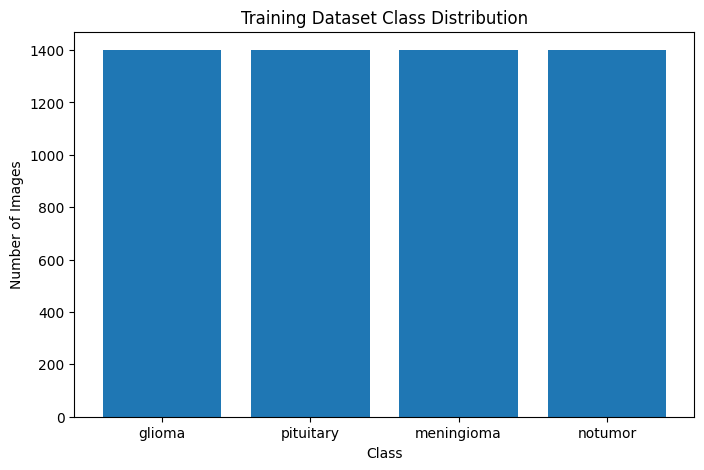

In [16]:
plt.figure(figsize=(8, 5))

plt.bar(train_counts.keys(), train_counts.values())

plt.title("Training Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.show()

# Display sample MRI images

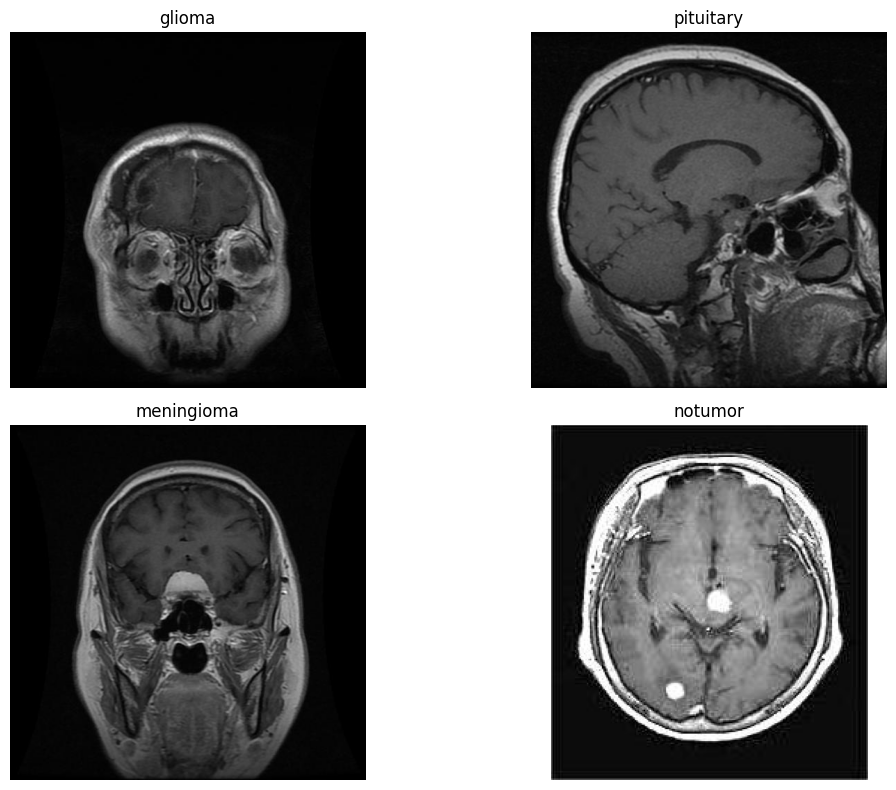

In [17]:
plt.figure(figsize=(12, 8))

for i, class_name in enumerate(classes):

    class_path = os.path.join(train_path, class_name)
    image_name = os.listdir(class_path)[0]
    image_path = os.path.join(class_path, image_name)

    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 2, i + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

# Check image dimensions

In [19]:
image_sizes = []

for class_name in classes:

    class_path = os.path.join(train_path, class_name)

    for image_name in os.listdir(class_path):

        image_path = os.path.join(class_path, image_name)
        image = cv2.imread(image_path)

        if image is not None:
            height, width = image.shape[:2]
            image_sizes.append((width, height))

In [20]:
from collections import Counter

size_counts = Counter(image_sizes)

size_counts.most_common(10)

[((512, 512), 4012),
 ((225, 225), 253),
 ((630, 630), 69),
 ((201, 251), 40),
 ((236, 236), 39),
 ((442, 442), 38),
 ((150, 198), 33),
 ((232, 217), 32),
 ((228, 221), 32),
 ((428, 417), 31)]

# Check color channels

In [21]:
sample_path = os.path.join(
    train_path,
    classes[0],
    os.listdir(os.path.join(train_path, classes[0]))[0]
)

sample_image = cv2.imread(sample_path)

print("Shape:", sample_image.shape)

Shape: (512, 512, 3)


# Check grayscale representation

In [22]:
gray_image = cv2.cvtColor(sample_image, cv2.COLOR_BGR2GRAY)

print("Original shape:", sample_image.shape)
print("Grayscale shape:", gray_image.shape)

Original shape: (512, 512, 3)
Grayscale shape: (512, 512)


In [23]:
print(train_counts)
print(test_counts)

{'glioma': 1400, 'pituitary': 1400, 'meningioma': 1400, 'notumor': 1400}
{'glioma': 400, 'pituitary': 400, 'meningioma': 400, 'notumor': 400}


In [24]:
print("Shape:", sample_image.shape)

Shape: (512, 512, 3)


In [25]:
size_counts.most_common(10)

[((512, 512), 4012),
 ((225, 225), 253),
 ((630, 630), 69),
 ((201, 251), 40),
 ((236, 236), 39),
 ((442, 442), 38),
 ((150, 198), 33),
 ((232, 217), 32),
 ((228, 221), 32),
 ((428, 417), 31)]

# Check wheather any invalid image

In [26]:
invalid_images = []

for split_path in [train_path, test_path]:

    for class_name in os.listdir(split_path):

        class_path = os.path.join(split_path, class_name)

        for image_name in os.listdir(class_path):

            image_path = os.path.join(class_path, image_name)
            image = cv2.imread(image_path)

            if image is None:
                invalid_images.append(image_path)

print("Invalid images:", len(invalid_images))

Invalid images: 0


## 2. Image Preprocessing

In [27]:
import cv2
import numpy as np

def preprocess_image(image_path):

    # Read image
    image = cv2.imread(image_path)

    # Check if image was loaded
    if image is None:
        return None

    # Convert BGR to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Resize to fixed dimensions
    resized = cv2.resize(gray, (128, 128))

    # Apply Gaussian blur
    blurred = cv2.GaussianBlur(resized, (5, 5), 0)

    # Normalize pixel values from 0-255 to 0-1
    normalized = blurred / 255.0

    return normalized

In [28]:
sample_image_path = os.path.join(
    train_path,
    "glioma",
    os.listdir(os.path.join(train_path, "glioma"))[0]
)

processed_image = preprocess_image(sample_image_path)

print("Processed shape:", processed_image.shape)
print("Minimum pixel value:", processed_image.min())
print("Maximum pixel value:", processed_image.max())

Processed shape: (128, 128)
Minimum pixel value: 0.0
Maximum pixel value: 0.7176470588235294


# Compare Original vs Processed

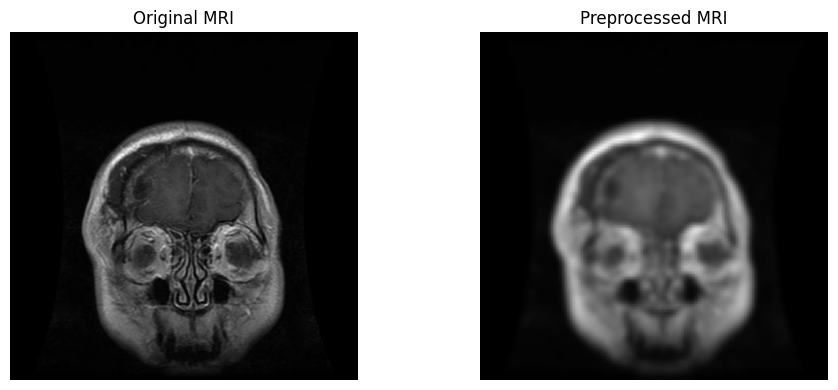

In [29]:
original = cv2.imread(sample_image_path)
original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(original_rgb)
plt.title("Original MRI")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(processed_image, cmap="gray")
plt.title("Preprocessed MRI")
plt.axis("off")

plt.tight_layout()
plt.show()

# GLCM Feature Extraction

# Install/Import GLCM

In [30]:
from skimage.feature import graycomatrix, graycoprops

In [31]:
gray_uint8 = (processed_image * 255).astype(np.uint8)

print(gray_uint8.shape)
print(gray_uint8.min(), gray_uint8.max())

(128, 128)
0 183


# Calculate GLCM

In [32]:
glcm = graycomatrix(
    gray_uint8,
    distances=[1],
    angles=[0],
    levels=256,
    symmetric=True,
    normed=True
)

# Extract the five features

In [33]:
contrast = graycoprops(glcm, 'contrast')[0, 0]
dissimilarity = graycoprops(glcm, 'dissimilarity')[0, 0]
homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]
energy = graycoprops(glcm, 'energy')[0, 0]
correlation = graycoprops(glcm, 'correlation')[0, 0]

print("Contrast:", contrast)
print("Dissimilarity:", dissimilarity)
print("Homogeneity:", homogeneity)
print("Energy:", energy)
print("Correlation:", correlation)

Contrast: 49.69943405511811
Dissimilarity: 3.1086368110236227
Homogeneity: 0.6336740683281187
Energy: 0.2960540841721761
Correlation: 0.9817046601125332


# 3. Feature Extraction
### GLCM + Intensity Features

In [35]:
from skimage.feature import graycomatrix, graycoprops

def extract_features(image_path):


    # 1. Read image
    image = cv2.imread(image_path)

    if image is None:
        return None

    # 2. Grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # 3. Resize
    resized = cv2.resize(gray, (128, 128))

    # 4. Gaussian Blur
    blurred = cv2.GaussianBlur(resized, (5, 5), 0)

    # 5. Normalize
    normalized = blurred / 255.0

    # Convert back to uint8 for GLCM
    gray_uint8 = (normalized * 255).astype(np.uint8)

    # 6. GLCM
    glcm = graycomatrix(
        gray_uint8,
        distances=[1],
        angles=[0],
        levels=256,
        symmetric=True,
        normed=True
    )

    contrast = graycoprops(glcm, 'contrast')[0, 0]
    dissimilarity = graycoprops(glcm, 'dissimilarity')[0, 0]
    homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]
    energy = graycoprops(glcm, 'energy')[0, 0]
    correlation = graycoprops(glcm, 'correlation')[0, 0]

    # 7. Intensity features
    mean = np.mean(normalized)
    std = np.std(normalized)
    variance = np.var(normalized)
    minimum = np.min(normalized)
    maximum = np.max(normalized)
    median = np.median(normalized)

    # 8. Return all features
    return [
        contrast,
        dissimilarity,
        homogeneity,
        energy,
        correlation,
        mean,
        std,
        variance,
        minimum,
        maximum,
        median
    ]

# Test

In [36]:
features = extract_features(sample_image_path)

print(features)
print("Number of features:", len(features))

[np.float64(49.69943405511811), np.float64(3.1086368110236227), np.float64(0.6336740683281187), np.float64(0.2960540841721761), np.float64(0.9817046601125332), np.float64(0.09898561963848039), np.float64(0.14422947709624348), np.float64(0.020802142063455823), np.float64(0.0), np.float64(0.7176470588235294), np.float64(0.011764705882352941)]
Number of features: 11


In [37]:
feature_names = [
    "glcm_contrast",
    "glcm_dissimilarity",
    "glcm_homogeneity",
    "glcm_energy",
    "glcm_correlation",
    "intensity_mean",
    "intensity_std",
    "intensity_variance",
    "intensity_min",
    "intensity_max",
    "intensity_median"
]

print(len(feature_names))

11


# Extract Features From All Training Images

In [38]:
X_train = []
y_train = []

for class_name in classes:

    class_path = os.path.join(train_path, class_name)

    print(f"Processing {class_name}...")

    for image_name in os.listdir(class_path):

        image_path = os.path.join(class_path, image_name)

        features = extract_features(image_path)

        if features is not None:
            X_train.append(features)
            y_train.append(class_name)

print("Training images processed:", len(X_train))
print("Training labels:", len(y_train))

Processing glioma...
Processing pituitary...
Processing meningioma...
Processing notumor...
Training images processed: 5600
Training labels: 5600


# Extract Features From Testing Images

In [39]:
X_test = []
y_test = []

for class_name in classes:

    class_path = os.path.join(test_path, class_name)

    print(f"Processing {class_name}...")

    for image_name in os.listdir(class_path):

        image_path = os.path.join(class_path, image_name)

        features = extract_features(image_path)

        if features is not None:
            X_test.append(features)
            y_test.append(class_name)

print("Testing images processed:", len(X_test))
print("Testing labels:", len(y_test))

Processing glioma...
Processing pituitary...
Processing meningioma...
Processing notumor...
Testing images processed: 1600
Testing labels: 1600


# Convert to Pandas DataFrame

In [40]:
X_train_df = pd.DataFrame(
    X_train,
    columns=feature_names
)

X_test_df = pd.DataFrame(
    X_test,
    columns=feature_names
)

In [41]:
print("Training shape:", X_train_df.shape)
print("Testing shape:", X_test_df.shape)

Training shape: (5600, 11)
Testing shape: (1600, 11)


In [42]:
X_train_df["label"] = y_train
X_test_df["label"] = y_test

In [43]:
X_train_df.head()

,glcm_contrast,glcm_dissimilarity,glcm_homogeneity,glcm_energy,glcm_correlation,intensity_mean,intensity_std,intensity_variance,intensity_min,intensity_max,intensity_median,label
0,49.699434,3.108637,0.633674,0.296054,0.981705,0.098986,0.144229,0.020802,0.0,0.717647,0.011765,glioma
1,37.384104,2.755782,0.624897,0.259554,0.978773,0.098481,0.116245,0.013513,0.0,0.556863,0.011765,glioma
2,58.341658,3.680610,0.559824,0.221522,0.978892,0.141736,0.145759,0.021246,0.0,0.670588,0.058824,glioma
3,52.085876,3.394931,0.562340,0.229879,0.974459,0.125315,0.125228,0.015682,0.0,0.517647,0.117647,glioma
4,54.696604,3.290108,0.621020,0.268549,0.973139,0.102315,0.124971,0.015618,0.0,0.525490,0.011765,glioma


# Prepare Data for Machine Learning

In [44]:
# Separate features and labels

X_train = X_train_df.drop("label", axis=1)
y_train = X_train_df["label"]

X_test = X_test_df.drop("label", axis=1)
y_test = X_test_df["label"]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (5600, 11)
y_train: (5600,)
X_test: (1600, 11)
y_test: (1600,)


# Feature Scaling

In [45]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [46]:
print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

Scaled training shape: (5600, 11)
Scaled testing shape: (1600, 11)


# First Model: SVM

In [47]:
from sklearn.svm import SVC

In [48]:
svm_model = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale"
)

In [49]:
svm_model.fit(X_train_scaled, y_train)

SVC()

In [50]:
y_pred = svm_model.predict(X_test_scaled)

# Evaluate the Baseline

In [51]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [52]:
accuracy = accuracy_score(y_test, y_pred)

print("SVM Accuracy:", accuracy)
print("SVM Accuracy (%):", accuracy * 100)

SVM Accuracy: 0.716875
SVM Accuracy (%): 71.6875


In [53]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      glioma       0.69      0.52      0.59       400
  meningioma       0.62      0.55      0.59       400
     notumor       0.71      0.95      0.81       400
   pituitary       0.83      0.85      0.84       400

    accuracy                           0.72      1600
   macro avg       0.71      0.72      0.71      1600
weighted avg       0.71      0.72      0.71      1600



In [54]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[206  99  68  27]
 [ 57 221  83  39]
 [  8   6 380   6]
 [ 29  28   3 340]]


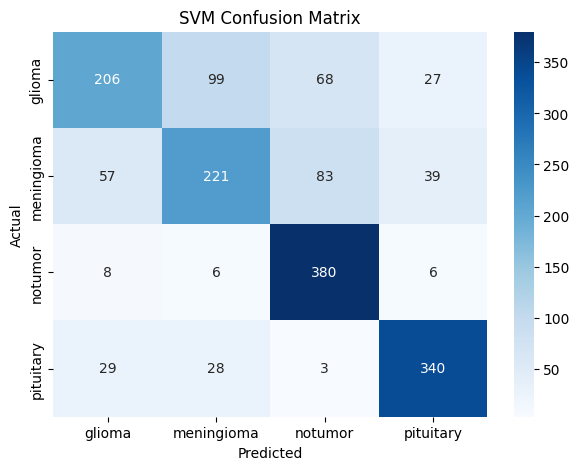

In [55]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=svm_model.classes_,
    yticklabels=svm_model.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")

plt.show()

# KNN

In [56]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

knn_pred = knn_model.predict(X_test_scaled)

knn_accuracy = accuracy_score(y_test, knn_pred)

print("KNN Accuracy:", knn_accuracy)
print("KNN Accuracy (%):", knn_accuracy * 100)

KNN Accuracy: 0.78875
KNN Accuracy (%): 78.875


# Logistic Regression

In [57]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000
)

lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_accuracy)
print("Logistic Regression Accuracy (%):", lr_accuracy * 100)

Logistic Regression Accuracy: 0.65125
Logistic Regression Accuracy (%): 65.125


# Random Forest

In [58]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)

rf_pred = rf_model.predict(X_test_scaled)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)
print("Random Forest Accuracy (%):", rf_accuracy * 100)

Random Forest Accuracy: 0.865625
Random Forest Accuracy (%): 86.5625


# Extra Trees

In [59]:
from sklearn.ensemble import ExtraTreesClassifier

et_model = ExtraTreesClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

et_model.fit(X_train_scaled, y_train)

et_pred = et_model.predict(X_test_scaled)

et_accuracy = accuracy_score(y_test, et_pred)

print("Extra Trees Accuracy:", et_accuracy)
print("Extra Trees Accuracy (%):", et_accuracy * 100)

Extra Trees Accuracy: 0.8775
Extra Trees Accuracy (%): 87.75


# XGBoost

In [60]:
!pip install -q xgboost

In [61]:
from xgboost import XGBClassifier

In [62]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print(label_encoder.classes_)

['glioma' 'meningioma' 'notumor' 'pituitary']


In [63]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric="mlogloss"
)

xgb_model.fit(X_train_scaled, y_train_encoded)

xgb_pred = xgb_model.predict(X_test_scaled)

xgb_accuracy = accuracy_score(y_test_encoded, xgb_pred)

print("XGBoost Accuracy:", xgb_accuracy)
print("XGBoost Accuracy (%):", xgb_accuracy * 100)

XGBoost Accuracy: 0.855625
XGBoost Accuracy (%): 85.5625


# Create the Comparison Table

In [64]:
results = pd.DataFrame({
    "Model": [
        "SVM",
        "KNN",
        "Logistic Regression",
        "Random Forest",
        "Extra Trees",
        "XGBoost"
    ],

    "Accuracy": [
        accuracy,
        knn_accuracy,
        lr_accuracy,
        rf_accuracy,
        et_accuracy,
        xgb_accuracy
    ]
})

results["Accuracy (%)"] = results["Accuracy"] * 100

results = results.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

results

,Model,Accuracy,Accuracy (%)
0,Extra Trees,0.877500,87.7500
1,Random Forest,0.865625,86.5625
2,XGBoost,0.855625,85.5625
3,KNN,0.788750,78.8750
4,SVM,0.716875,71.6875
5,Logistic Regression,0.651250,65.1250


# Proper Validation

In [65]:
from sklearn.model_selection import train_test_split

X_train_part, X_val, y_train_part, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("Training:", X_train_part.shape)
print("Validation:", X_val.shape)

Training: (4480, 11)
Validation: (1120, 11)


In [66]:
scaler_new = StandardScaler()

X_train_part_scaled = scaler_new.fit_transform(X_train_part)

X_val_scaled = scaler_new.transform(X_val)

In [67]:
scaler_new.fit_transform(X_val)

array([[-1.03206404, -1.1591083 ,  1.28150781, ..., -0.26831075,
        -1.83223784, -1.26062926],
       [-0.78869244, -1.14108416,  1.78154039, ..., -0.26831075,
         0.84461038, -1.22529808],
       [-0.43915397, -0.30388867,  0.11393997, ..., -0.26831075,
        -0.91117179,  0.11728691],
       ...,
       [-0.90780236, -1.10258815,  1.07433066, ..., -0.26831075,
        -1.08387167, -1.11930453],
       [ 3.44477556,  3.14447112, -2.09918274, ..., -0.26831075,
         1.99594294,  4.18037307],
       [-0.59860692, -0.24280685, -0.70720032, ..., -0.26831075,
         0.12502752,  1.38920953]])

# Evaluate Extra Trees on Validation

In [68]:
et_model_val = ExtraTreesClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

et_model_val.fit(X_train_part, y_train_part)

et_val_pred = et_model_val.predict(X_val)

et_val_accuracy = accuracy_score(y_val, et_val_pred)

print("Extra Trees Validation Accuracy:",
      et_val_accuracy * 100)

Extra Trees Validation Accuracy: 89.55357142857143


In [69]:
X_train_part
X_val

,glcm_contrast,glcm_dissimilarity,glcm_homogeneity,glcm_energy,glcm_correlation,intensity_mean,intensity_std,intensity_variance,intensity_min,intensity_max,intensity_median
835,40.463337,2.976255,0.624808,0.278124,0.970249,0.084589,0.102140,0.010433,0.0,0.458824,0.011765
2965,54.575049,3.006152,0.680213,0.329142,0.989818,0.129376,0.202544,0.041024,0.0,0.823529,0.015686
2193,74.842766,4.394808,0.495437,0.167066,0.968535,0.154070,0.135390,0.018330,0.0,0.584314,0.164706
1242,93.085138,4.450664,0.492795,0.172768,0.966148,0.158111,0.145391,0.021138,0.0,0.698039,0.133333
1095,55.733145,3.663878,0.551068,0.245564,0.972663,0.115366,0.125136,0.015659,0.0,0.513725,0.058824
...,...,...,...,...,...,...,...,...,...,...,...
1227,63.925320,4.022269,0.530467,0.230893,0.972112,0.130014,0.132744,0.017621,0.0,0.564706,0.109804
928,72.924213,4.070251,0.577931,0.264827,0.970779,0.111814,0.138341,0.019138,0.0,0.576471,0.011765
702,47.668553,3.070005,0.601852,0.239671,0.979809,0.123925,0.134658,0.018133,0.0,0.560784,0.027451
3117,300.049397,10.114604,0.250215,0.040917,0.967793,0.539790,0.268499,0.072092,0.0,0.980392,0.615686


# Get Macro F1

In [70]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_val,
        et_val_pred
    )
)

              precision    recall  f1-score   support

      glioma       0.87      0.81      0.84       280
  meningioma       0.84      0.85      0.84       280
     notumor       0.95      0.96      0.96       280
   pituitary       0.91      0.96      0.94       280

    accuracy                           0.90      1120
   macro avg       0.89      0.90      0.89      1120
weighted avg       0.89      0.90      0.89      1120



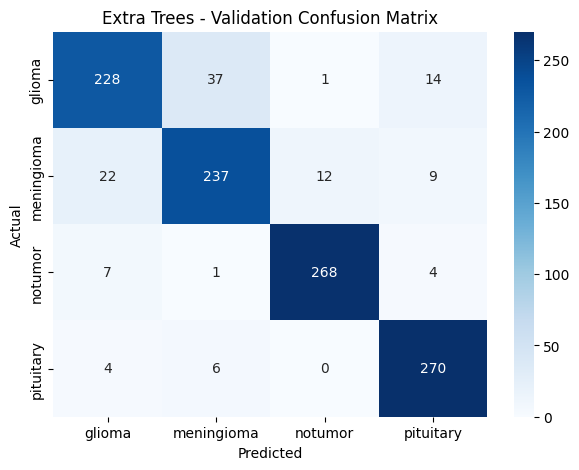

In [71]:
cm = confusion_matrix(y_val, et_val_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=et_model_val.classes_,
    yticklabels=et_model_val.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Extra Trees - Validation Confusion Matrix")

plt.show()

# Add HOG Features

In [72]:
from skimage.feature import hog

In [73]:
def extract_hog_features(image_path):

    # Read image
    image = cv2.imread(image_path)

    if image is None:
        return None

    # Grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Resize
    resized = cv2.resize(gray, (128, 128))

    # Gaussian blur
    blurred = cv2.GaussianBlur(resized, (5, 5), 0)

    # Normalize
    normalized = blurred / 255.0

    # HOG
    hog_features = hog(
        normalized,
        orientations=9,
        pixels_per_cell=(16, 16),
        cells_per_block=(2, 2),
        block_norm='L2-Hys'
    )

    return hog_features

# Test HOG on one image

In [74]:
sample_hog = extract_hog_features(sample_image_path)

print("Number of HOG features:", len(sample_hog))

Number of HOG features: 1764


# Extract HOG for the Training Images

In [77]:
X_train_hog = []
y_train_hog = []

for class_name in classes:

    class_path = os.path.join(train_path, class_name)

    print(f"Processing HOG - {class_name}...")

    for image_name in os.listdir(class_path):

        image_path = os.path.join(class_path, image_name)

        features = extract_hog_features(image_path)

        if features is not None:
            X_train_hog.append(features)
            y_train_hog.append(class_name)

print("Training HOG shape:", np.array(X_train_hog).shape)

Processing HOG - glioma...
Processing HOG - pituitary...
Processing HOG - meningioma...
Processing HOG - notumor...
Training HOG shape: (5600, 1764)


In [78]:
X_test_hog = []
y_test_hog = []

for class_name in classes:

    class_path = os.path.join(test_path, class_name)

    print(f"Processing HOG - {class_name}...")

    for image_name in os.listdir(class_path):

        image_path = os.path.join(class_path, image_name)

        features = extract_hog_features(image_path)

        if features is not None:
            X_test_hog.append(features)
            y_test_hog.append(class_name)

print("Testing HOG shape:", np.array(X_test_hog).shape)

Processing HOG - glioma...
Processing HOG - pituitary...
Processing HOG - meningioma...
Processing HOG - notumor...
Testing HOG shape: (1600, 1764)


# Convert to NumPy arrays

In [79]:
X_train_hog = np.array(X_train_hog)
X_test_hog = np.array(X_test_hog)

y_train_hog = np.array(y_train_hog)
y_test_hog = np.array(y_test_hog)

print(X_train_hog.shape)
print(X_test_hog.shape)

(5600, 1764)
(1600, 1764)


# Split HOG Training Data

In [80]:
from sklearn.model_selection import train_test_split

X_hog_train, X_hog_val, y_hog_train, y_hog_val = train_test_split(
    X_train_hog,
    y_train_hog,
    test_size=0.20,
    random_state=42,
    stratify=y_train_hog
)

print("HOG training:", X_hog_train.shape)
print("HOG validation:", X_hog_val.shape)

HOG training: (4480, 1764)
HOG validation: (1120, 1764)


# Train Extra Trees on HOG

In [81]:
et_hog = ExtraTreesClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

et_hog.fit(X_hog_train, y_hog_train)

ExtraTreesClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [82]:
y_hog_pred = et_hog.predict(X_hog_val)

Accuracy

In [83]:
hog_accuracy = accuracy_score(
    y_hog_val,
    y_hog_pred
)

print("HOG + Extra Trees Validation Accuracy:",
      hog_accuracy * 100)

HOG + Extra Trees Validation Accuracy: 92.05357142857142


# Check F1 Score

In [84]:
print(
    classification_report(
        y_hog_val,
        y_hog_pred
    )
)

              precision    recall  f1-score   support

      glioma       0.95      0.89      0.92       280
  meningioma       0.91      0.88      0.89       280
     notumor       0.96      0.92      0.94       280
   pituitary       0.87      0.99      0.93       280

    accuracy                           0.92      1120
   macro avg       0.92      0.92      0.92      1120
weighted avg       0.92      0.92      0.92      1120



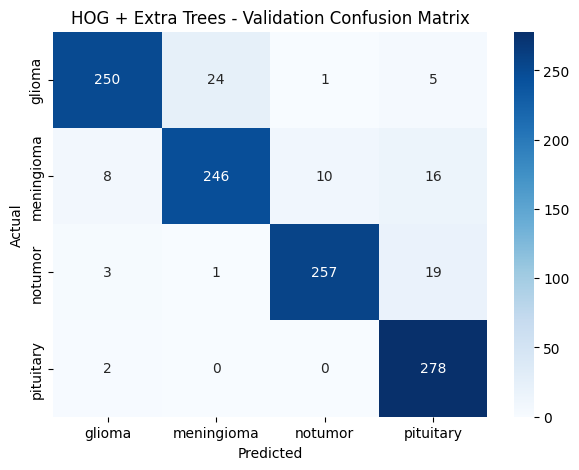

In [85]:
cm_hog = confusion_matrix(
    y_hog_val,
    y_hog_pred
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_hog,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=et_hog.classes_,
    yticklabels=et_hog.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("HOG + Extra Trees - Validation Confusion Matrix")

plt.show()

# Compare Our Two Experiments

In [86]:
comparison = pd.DataFrame({
    "Experiment": [
        "GLCM + Intensity",
        "HOG"
    ],
    "Model": [
        "Extra Trees",
        "Extra Trees"
    ],
    "Validation Accuracy (%)": [
        et_val_accuracy * 100,
        hog_accuracy * 100
    ]
})

comparison


,Experiment,Model,Validation Accuracy (%)
0,GLCM + Intensity,Extra Trees,89.553571
1,HOG,Extra Trees,92.053571


# Combine HOG + GLCM + Intensit

In [88]:
# convert our existing feature DataFrames to NumPy
X_train_basic = X_train_df.drop("label", axis=1).values
X_test_basic = X_test_df.drop("label", axis=1).values

In [90]:
#combine
X_train_combined = np.hstack([
    X_train_basic,
    X_train_hog
])

X_test_combined = np.hstack([
    X_test_basic,
    X_test_hog
])

print("Combined training shape:", X_train_combined.shape)
print("Combined testing shape:", X_test_combined.shape)

Combined training shape: (5600, 1775)
Combined testing shape: (1600, 1775)


# Create a Validation Split

In [91]:
X_comb_train, X_comb_val, y_comb_train, y_comb_val = train_test_split(
    X_train_combined,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("Training:", X_comb_train.shape)
print("Validation:", X_comb_val.shape)

Training: (4480, 1775)
Validation: (1120, 1775)


# Train Extra Trees on Combined Features

In [92]:
et_combined = ExtraTreesClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

et_combined.fit(
    X_comb_train,
    y_comb_train
)

ExtraTreesClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [93]:
y_comb_pred = et_combined.predict(X_comb_val)

In [94]:
combined_accuracy = accuracy_score(
    y_comb_val,
    y_comb_pred
)

print(
    "GLCM + Intensity + HOG Accuracy:",
    combined_accuracy * 100
)

GLCM + Intensity + HOG Accuracy: 92.23214285714286


# Classification Report

In [95]:
print(
    classification_report(
        y_comb_val,
        y_comb_pred
    )
)

              precision    recall  f1-score   support

      glioma       0.95      0.88      0.91       280
  meningioma       0.90      0.87      0.88       280
     notumor       0.96      0.95      0.95       280
   pituitary       0.89      1.00      0.94       280

    accuracy                           0.92      1120
   macro avg       0.92      0.92      0.92      1120
weighted avg       0.92      0.92      0.92      1120



## Confusion Matrix

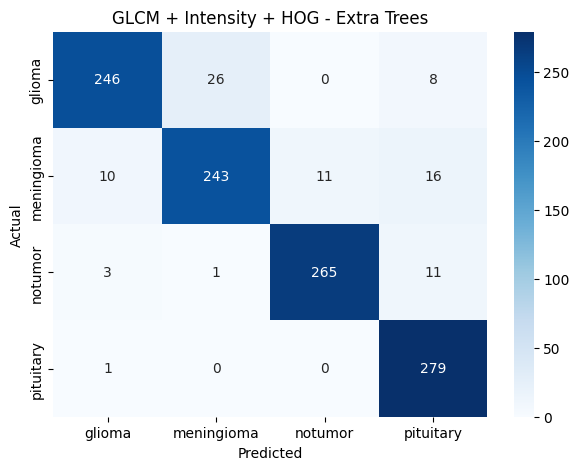

In [96]:
cm_combined = confusion_matrix(
    y_comb_val,
    y_comb_pred
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_combined,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=et_combined.classes_,
    yticklabels=et_combined.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("GLCM + Intensity + HOG - Extra Trees")

plt.show()

# Create LBP Features

In [97]:
from skimage.feature import local_binary_pattern

In [98]:
def extract_lbp_features(image_path):

    # Read image
    image = cv2.imread(image_path)

    if image is None:
        return None

    # Grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Resize
    resized = cv2.resize(gray, (128, 128))

    # Gaussian blur
    blurred = cv2.GaussianBlur(resized, (5, 5), 0)

    # LBP parameters
    radius = 1
    n_points = 8 * radius

    # Calculate LBP
    lbp = local_binary_pattern(
        blurred,
        n_points,
        radius,
        method="uniform"
    )

    # Number of bins for uniform LBP
    n_bins = n_points + 2

    # Calculate histogram
    histogram, _ = np.histogram(
        lbp.ravel(),
        bins=n_bins,
        range=(0, n_bins),
        density=True
    )

    return histogram

In [99]:
sample_lbp = extract_lbp_features(sample_image_path)

print("Number of LBP features:", len(sample_lbp))
print(sample_lbp)

Number of LBP features: 10
[0.00488281 0.01446533 0.01257324 0.06787109 0.20129395 0.14831543
 0.02618408 0.0291748  0.47875977 0.01647949]


# Extract LBP for Testing Data

In [100]:
X_train_lbp = []
y_train_lbp = []

for class_name in classes:

    class_path = os.path.join(train_path, class_name)

    print(f"Processing LBP - {class_name}...")

    for image_name in os.listdir(class_path):

        image_path = os.path.join(class_path, image_name)

        features = extract_lbp_features(image_path)

        if features is not None:
            X_train_lbp.append(features)
            y_train_lbp.append(class_name)

X_train_lbp = np.array(X_train_lbp)
y_train_lbp = np.array(y_train_lbp)

print("Training LBP shape:", X_train_lbp.shape)

Processing LBP - glioma...
Processing LBP - pituitary...
Processing LBP - meningioma...
Processing LBP - notumor...
Training LBP shape: (5600, 10)


# Extract LBP for Testing Data

In [101]:
X_test_lbp = []
y_test_lbp = []

for class_name in classes:

    class_path = os.path.join(test_path, class_name)

    print(f"Processing LBP - {class_name}...")

    for image_name in os.listdir(class_path):

        image_path = os.path.join(class_path, image_name)

        features = extract_lbp_features(image_path)

        if features is not None:
            X_test_lbp.append(features)
            y_test_lbp.append(class_name)

X_test_lbp = np.array(X_test_lbp)
y_test_lbp = np.array(y_test_lbp)

print("Testing LBP shape:", X_test_lbp.shape)

Processing LBP - glioma...
Processing LBP - pituitary...
Processing LBP - meningioma...
Processing LBP - notumor...
Testing LBP shape: (1600, 10)


# Build the Full Feature Set

In [102]:
X_train_full = np.hstack([
    X_train_basic,
    X_train_hog,
    X_train_lbp
])

X_test_full = np.hstack([
    X_test_basic,
    X_test_hog,
    X_test_lbp
])

print("Full training shape:", X_train_full.shape)
print("Full testing shape:", X_test_full.shape)

Full training shape: (5600, 1785)
Full testing shape: (1600, 1785)


# Validation Split for Full Features

In [103]:
X_full_train, X_full_val, y_full_train, y_full_val = train_test_split(
    X_train_full,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("Full training:", X_full_train.shape)
print("Full validation:", X_full_val.shape)

Full training: (4480, 1785)
Full validation: (1120, 1785)


# Train Extra Trees

In [104]:
et_full = ExtraTreesClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

et_full.fit(
    X_full_train,
    y_full_train
)

ExtraTreesClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [105]:
y_full_pred = et_full.predict(X_full_val)

In [106]:
full_accuracy = accuracy_score(
    y_full_val,
    y_full_pred
)

print(
    "GLCM + Intensity + HOG + LBP Accuracy:",
    full_accuracy * 100
)

GLCM + Intensity + HOG + LBP Accuracy: 91.875


In [107]:
print(
    classification_report(
        y_full_val,
        y_full_pred
    )
)

              precision    recall  f1-score   support

      glioma       0.95      0.87      0.91       280
  meningioma       0.89      0.87      0.88       280
     notumor       0.96      0.94      0.95       280
   pituitary       0.89      0.99      0.94       280

    accuracy                           0.92      1120
   macro avg       0.92      0.92      0.92      1120
weighted avg       0.92      0.92      0.92      1120



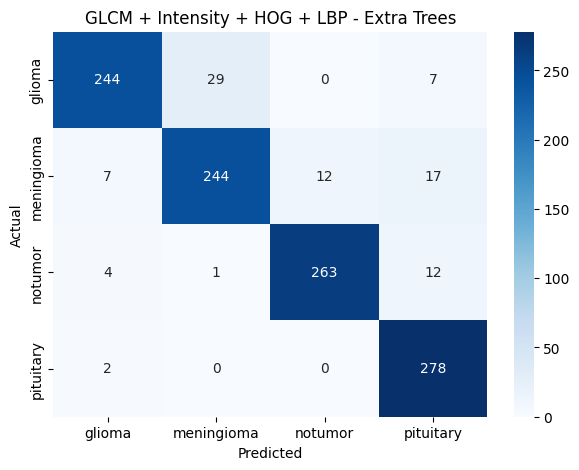

In [108]:
cm_full = confusion_matrix(
    y_full_val,
    y_full_pred
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_full,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=et_full.classes_,
    yticklabels=et_full.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("GLCM + Intensity + HOG + LBP - Extra Trees")

plt.show()

# Our Experiment Table

In [109]:
experiment_results = pd.DataFrame({
    "Experiment": [
        "GLCM + Intensity",
        "HOG",
        "GLCM + Intensity + HOG",
        "GLCM + Intensity + HOG + LBP"
    ],

    "Validation Accuracy (%)": [
        et_val_accuracy * 100,
        hog_accuracy * 100,
        combined_accuracy * 100,
        full_accuracy * 100
    ]
})

experiment_results

,Experiment,Validation Accuracy (%)
0,GLCM + Intensity,89.553571
1,HOG,92.053571
2,GLCM + Intensity + HOG,92.232143
3,GLCM + Intensity + HOG + LBP,91.875000


# **Feature Selection**

# Get Feature Importance

In [110]:
importances = et_combined.feature_importances_

print("Number of features:", len(importances))
print("Importance shape:", importances.shape)

Number of features: 1775
Importance shape: (1775,)


In [111]:
indices = np.argsort(importances)[::-1]

print("Top 20 feature indices:")
print(indices[:20])

Top 20 feature indices:
[   9    5 1019    6 1010    7    3    1 1244    0  281    2  533  785
  992 1689 1618  154  758 1591]


# Visualize Top Features

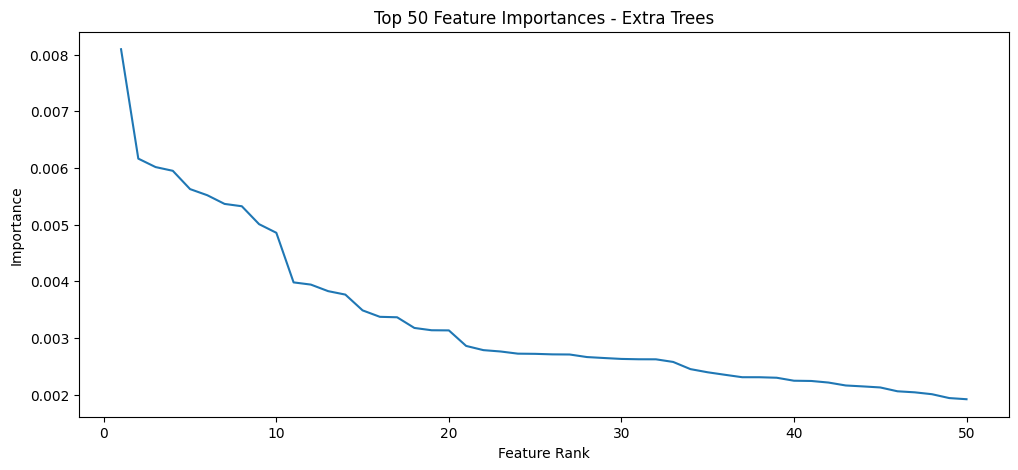

In [112]:
plt.figure(figsize=(12, 5))

plt.plot(
    range(1, 51),
    importances[indices[:50]]
)

plt.xlabel("Feature Rank")
plt.ylabel("Importance")
plt.title("Top 50 Feature Importances - Extra Trees")

plt.show()

# Select Top 500 Features

In [113]:
top_k = 500

selected_indices = indices[:top_k]

X_comb_train_selected = X_comb_train[:, selected_indices]
X_comb_val_selected = X_comb_val[:, selected_indices]

print("Selected training shape:",
      X_comb_train_selected.shape)

print("Selected validation shape:",
      X_comb_val_selected.shape)

Selected training shape: (4480, 500)
Selected validation shape: (1120, 500)


# Train Extra Trees With 500 Features

In [114]:
et_selected = ExtraTreesClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

et_selected.fit(
    X_comb_train_selected,
    y_comb_train
)

ExtraTreesClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [115]:
y_selected_pred = et_selected.predict(
    X_comb_val_selected
)

In [116]:
selected_accuracy = accuracy_score(
    y_comb_val,
    y_selected_pred
)

print(
    "Top 500 Features Accuracy:",
    selected_accuracy * 100
)

Top 500 Features Accuracy: 92.58928571428572


In [117]:
print(
    classification_report(
        y_comb_val,
        y_selected_pred
    )
)

              precision    recall  f1-score   support

      glioma       0.95      0.87      0.91       280
  meningioma       0.90      0.89      0.89       280
     notumor       0.96      0.95      0.95       280
   pituitary       0.91      0.99      0.95       280

    accuracy                           0.93      1120
   macro avg       0.93      0.93      0.93      1120
weighted avg       0.93      0.93      0.93      1120



# Test different feature counts

In [118]:
feature_counts = [250, 500, 750, 1000]

feature_selection_results = []

for k in feature_counts:

    selected_indices = indices[:k]

    X_train_selected = X_comb_train[:, selected_indices]
    X_val_selected = X_comb_val[:, selected_indices]

    model = ExtraTreesClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train_selected,
        y_comb_train
    )

    pred = model.predict(
        X_val_selected
    )

    acc = accuracy_score(
        y_comb_val,
        pred
    )

    feature_selection_results.append({
        "Features": k,
        "Accuracy (%)": acc * 100
    })

feature_selection_results = pd.DataFrame(
    feature_selection_results
)

feature_selection_results

,Features,Accuracy (%)
0,250,91.785714
1,500,92.589286
2,750,92.053571
3,1000,92.142857


# Hyperparameter Tuning

In [119]:
ExtraTreesClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

ExtraTreesClassifier(n_estimators=200, n_jobs=-1, random_state=42)

# Use RandomizedSearchCV

In [120]:
from sklearn.model_selection import RandomizedSearchCV

In [121]:
param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", 0.5]
}

# Important: Use the 500 Selected Features




In [122]:
top_k = 500

selected_indices_500 = indices[:top_k]

X_train_500 = X_comb_train[:, selected_indices_500]
X_val_500 = X_comb_val[:, selected_indices_500]

print(X_train_500.shape)
print(X_val_500.shape)

(4480, 500)
(1120, 500)


# Hyperparameter Search

In [123]:
et_base = ExtraTreesClassifier(
    random_state=42,
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=et_base,
    param_distributions=param_grid,
    n_iter=20,
    scoring="f1_macro",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [124]:
random_search.fit(
    X_train_500,
    y_comb_train
)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


RandomizedSearchCV(cv=3,
                   estimator=ExtraTreesClassifier(n_jobs=-1, random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'max_depth': [None, 10, 20, 30],
                                        'max_features': ['sqrt', 'log2', 0.5],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 500]},
                   random_state=42, scoring='f1_macro', verbose=1)

# See the Best Parameters

In [125]:
print("Best Parameters:")
print(random_search.best_params_)

Best Parameters:
{'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': None}


In [126]:
print("Best CV Macro F1:")
print(random_search.best_score_)

Best CV Macro F1:
0.9083367082583041


# Evaluate the Tuned Model on Validation

In [128]:
best_et = random_search.best_estimator_

In [129]:
y_tuned_pred = best_et.predict(X_val_500)

In [130]:
tuned_accuracy = accuracy_score(
    y_comb_val,
    y_tuned_pred
)

print(
    "Tuned Extra Trees Validation Accuracy:",
    tuned_accuracy * 100
)

Tuned Extra Trees Validation Accuracy: 93.30357142857143


In [131]:
print(
    classification_report(
        y_comb_val,
        y_tuned_pred
    )
)

              precision    recall  f1-score   support

      glioma       0.98      0.86      0.91       280
  meningioma       0.88      0.90      0.89       280
     notumor       0.95      0.98      0.96       280
   pituitary       0.93      1.00      0.96       280

    accuracy                           0.93      1120
   macro avg       0.93      0.93      0.93      1120
weighted avg       0.93      0.93      0.93      1120



## Final Test Evaluation

In [132]:
X_test_combined

array([[9.98618971e+01, 5.06268455e+00, 4.77816051e-01, ...,
        1.51180015e-02, 4.97992853e-03, 0.00000000e+00],
       [8.32721457e+01, 4.16830709e+00, 5.12666267e-01, ...,
        2.51616051e-02, 4.21560051e-02, 3.97137927e-02],
       [1.07932640e+02, 5.53389518e+00, 4.73325477e-01, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       ...,
       [1.49481484e+02, 6.27048474e+00, 3.79487547e-01, ...,
        1.57475569e-03, 0.00000000e+00, 0.00000000e+00],
       [3.86961122e+01, 3.19180610e+00, 4.96284727e-01, ...,
        7.98496126e-02, 0.00000000e+00, 0.00000000e+00],
       [5.81849163e+01, 3.40698819e+00, 6.20411833e-01, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00]])

In [133]:
X_test_500 = X_test_combined[:, selected_indices_500]

print("Final test feature shape:", X_test_500.shape)

Final test feature shape: (1600, 500)


# Final Prediction

In [134]:
final_test_pred = best_et.predict(X_test_500)

In [135]:
final_test_accuracy = accuracy_score(
    y_test,
    final_test_pred
)

print(
    "FINAL TEST ACCURACY:",
    final_test_accuracy * 100
)

FINAL TEST ACCURACY: 87.0


In [136]:
print(
    classification_report(
        y_test,
        final_test_pred
    )
)

              precision    recall  f1-score   support

      glioma       0.93      0.66      0.77       400
  meningioma       0.82      0.85      0.84       400
     notumor       0.84      1.00      0.91       400
   pituitary       0.91      0.97      0.94       400

    accuracy                           0.87      1600
   macro avg       0.88      0.87      0.87      1600
weighted avg       0.88      0.87      0.87      1600



# Final Confusion Matrix

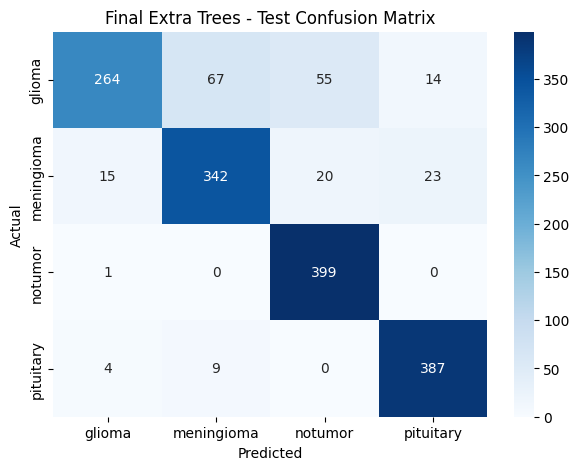

In [137]:
final_cm = confusion_matrix(
    y_test,
    final_test_pred
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=best_et.classes_,
    yticklabels=best_et.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Final Extra Trees - Test Confusion Matrix")

plt.show()

In [138]:
import pandas as pd
import matplotlib.pyplot as plt

# Basic features
feature_names = [
    "glcm_contrast",
    "glcm_dissimilarity",
    "glcm_homogeneity",
    "glcm_energy",
    "glcm_correlation",
    "intensity_mean",
    "intensity_std",
    "intensity_variance",
    "intensity_min",
    "intensity_max",
    "intensity_median"
]

train_basic_df = pd.DataFrame(
    X_train_basic,
    columns=feature_names
)

test_basic_df = pd.DataFrame(
    X_test_basic,
    columns=feature_names
)

In [139]:
train_basic_df.describe().T

,count,mean,std,min,25%,50%,75%,max
glcm_contrast,5600.0,101.005912,59.310404,13.336491,66.985559,85.986282,110.103377,480.394624
glcm_dissimilarity,5600.0,4.915013,1.665485,1.444021,3.886411,4.666615,5.482268,13.458600
glcm_homogeneity,5600.0,0.483091,0.109312,0.156573,0.400722,0.482919,0.553899,0.776331
glcm_energy,5600.0,0.190798,0.101091,0.018688,0.107382,0.176142,0.257063,0.662033
glcm_correlation,5600.0,0.970829,0.009254,0.920379,0.965700,0.971531,0.976736,0.994623
intensity_mean,5600.0,0.184147,0.068222,0.058828,0.137518,0.172399,0.211368,0.539790
intensity_std,5600.0,0.162059,0.043411,0.071382,0.135399,0.152471,0.176154,0.347872
intensity_variance,5600.0,0.028147,0.017079,0.005095,0.018333,0.023247,0.031030,0.121015
intensity_min,5600.0,0.004421,0.016692,0.000000,0.000000,0.000000,0.000000,0.180392
intensity_max,5600.0,0.710820,0.136829,0.329412,0.615686,0.686275,0.785294,1.000000


In [140]:
test_basic_df.describe().T

,count,mean,std,min,25%,50%,75%,max
glcm_contrast,1600.0,111.217280,66.757702,17.139456,69.951495,90.400529,127.613620,474.942913
glcm_dissimilarity,1600.0,5.182295,1.758912,1.795891,4.095088,4.813853,5.783757,13.301550
glcm_homogeneity,1600.0,0.472737,0.105752,0.187453,0.391727,0.468096,0.541649,0.753680
glcm_energy,1600.0,0.192959,0.109240,0.023189,0.104080,0.175100,0.258229,0.662033
glcm_correlation,1600.0,0.970761,0.008841,0.940041,0.965601,0.971053,0.976753,0.994623
intensity_mean,1600.0,0.195605,0.074147,0.060130,0.142233,0.181964,0.224937,0.539790
intensity_std,1600.0,0.169285,0.046628,0.071966,0.136979,0.158680,0.188049,0.342031
intensity_variance,1600.0,0.030830,0.018399,0.005179,0.018763,0.025179,0.035362,0.116985
intensity_min,1600.0,0.005453,0.020229,0.000000,0.000000,0.000000,0.000000,0.239216
intensity_max,1600.0,0.737360,0.142162,0.384314,0.631373,0.709804,0.850980,1.000000


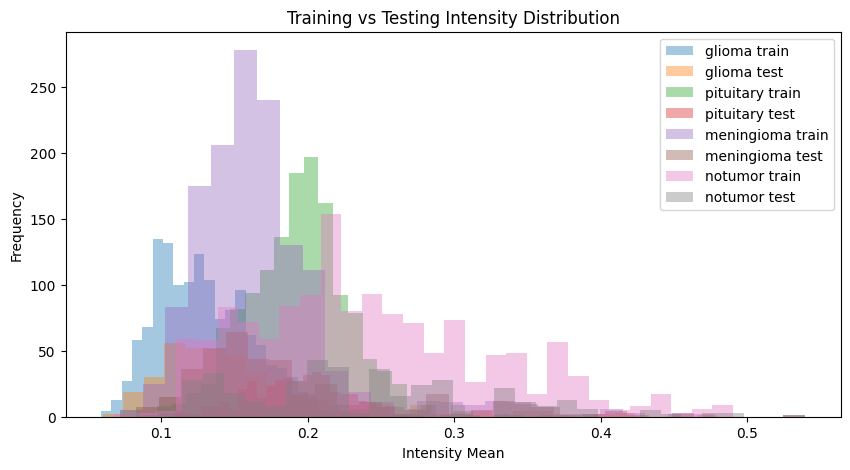

In [141]:
plt.figure(figsize=(10, 5))

for class_name in classes:

    train_values = X_train_basic[
        y_train == class_name
    ][:, 5]

    test_values = X_test_basic[
        y_test == class_name
    ][:, 5]

    plt.hist(
        train_values,
        bins=30,
        alpha=0.4,
        label=f"{class_name} train"
    )

    plt.hist(
        test_values,
        bins=30,
        alpha=0.4,
        label=f"{class_name} test"
    )

plt.xlabel("Intensity Mean")
plt.ylabel("Frequency")
plt.title("Training vs Testing Intensity Distribution")
plt.legend()
plt.show()

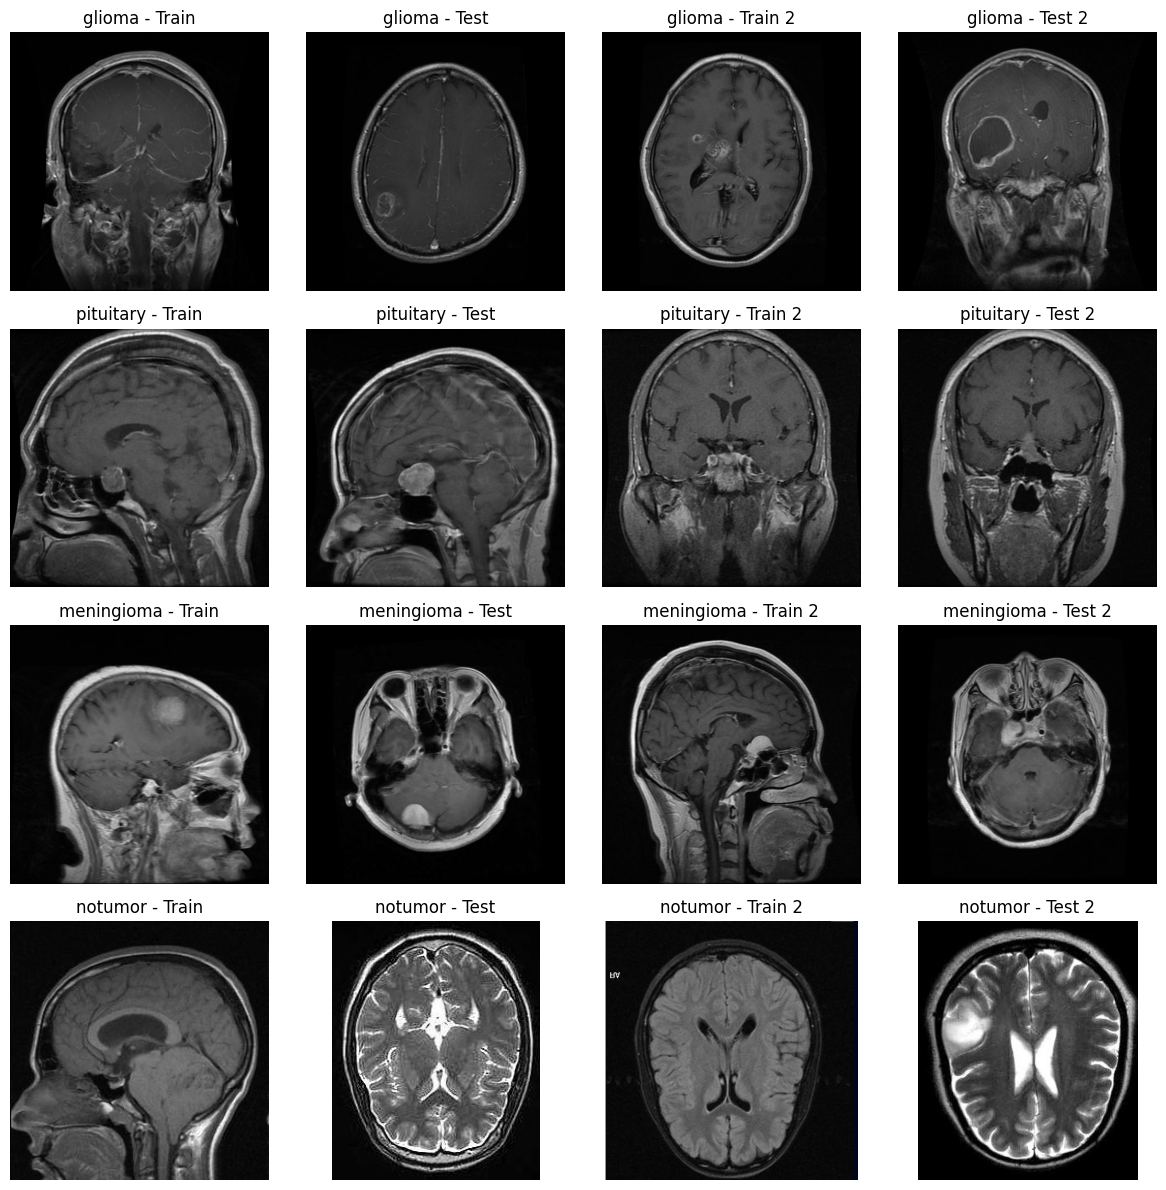

In [142]:
import random
import matplotlib.pyplot as plt
import cv2
import os

fig, axes = plt.subplots(
    4, 4,
    figsize=(12, 12)
)

for row, class_name in enumerate(classes):

    train_class_path = os.path.join(
        train_path,
        class_name
    )

    test_class_path = os.path.join(
        test_path,
        class_name
    )

    train_image = random.choice(
        os.listdir(train_class_path)
    )

    test_image = random.choice(
        os.listdir(test_class_path)
    )

    train_img = cv2.imread(
        os.path.join(train_class_path, train_image)
    )

    test_img = cv2.imread(
        os.path.join(test_class_path, test_image)
    )

    axes[row, 0].imshow(
        cv2.cvtColor(train_img, cv2.COLOR_BGR2RGB)
    )

    axes[row, 0].set_title(
        f"{class_name} - Train"
    )

    axes[row, 1].imshow(
        cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
    )

    axes[row, 1].set_title(
        f"{class_name} - Test"
    )

    # Additional random samples
    train_image2 = random.choice(
        os.listdir(train_class_path)
    )

    test_image2 = random.choice(
        os.listdir(test_class_path)
    )

    train_img2 = cv2.imread(
        os.path.join(train_class_path, train_image2)
    )

    test_img2 = cv2.imread(
        os.path.join(test_class_path, test_image2)
    )

    axes[row, 2].imshow(
        cv2.cvtColor(train_img2, cv2.COLOR_BGR2RGB)
    )

    axes[row, 2].set_title(
        f"{class_name} - Train 2"
    )

    axes[row, 3].imshow(
        cv2.cvtColor(test_img2, cv2.COLOR_BGR2RGB)
    )

    axes[row, 3].set_title(
        f"{class_name} - Test 2"
    )

for ax in axes.flat:
    ax.axis("off")

plt.tight_layout()
plt.show()

# Compare Train/Test Statistics Per Class

In [143]:
import pandas as pd
import numpy as np

feature_names = [
    "glcm_contrast",
    "glcm_dissimilarity",
    "glcm_homogeneity",
    "glcm_energy",
    "glcm_correlation",
    "intensity_mean",
    "intensity_std",
    "intensity_variance",
    "intensity_min",
    "intensity_max",
    "intensity_median"
]

train_basic_df = pd.DataFrame(
    X_train_basic,
    columns=feature_names
)

train_basic_df["label"] = y_train

test_basic_df = pd.DataFrame(
    X_test_basic,
    columns=feature_names
)

test_basic_df["label"] = y_test

In [144]:
for class_name in classes:

    print("\n" + "=" * 60)
    print("CLASS:", class_name)
    print("=" * 60)

    train_class = train_basic_df[
        train_basic_df["label"] == class_name
    ]

    test_class = test_basic_df[
        test_basic_df["label"] == class_name
    ]

    comparison = pd.DataFrame({
        "Train Mean": train_class[feature_names].mean(),
        "Test Mean": test_class[feature_names].mean(),
        "Train Std": train_class[feature_names].std(),
        "Test Std": test_class[feature_names].std()
    })

    print(comparison)


CLASS: glioma
                    Train Mean  Test Mean  Train Std   Test Std
glcm_contrast        63.945589  84.979506  20.590524  56.441834
glcm_dissimilarity    3.601807   4.265671   0.838302   1.619419
glcm_homogeneity      0.576837   0.534213   0.085982   0.108079
glcm_energy           0.239122   0.221348   0.081128   0.093051
glcm_correlation      0.973613   0.972787   0.005981   0.007137
intensity_mean        0.130170   0.159083   0.033645   0.067692
intensity_std         0.136196   0.150602   0.021736   0.036226
intensity_variance    0.019022   0.023990   0.006007   0.013246
intensity_min         0.000000   0.003265   0.000000   0.021310
intensity_max         0.610994   0.670294   0.088879   0.137902
intensity_median      0.076613   0.115289   0.074153   0.109493

CLASS: pituitary
                    Train Mean  Test Mean  Train Std   Test Std
glcm_contrast        90.946394  89.819631  23.109290  21.957852
glcm_dissimilarity    5.067455   5.002054   0.748302   0.652950
glcm_ho

# Quantify Distribution Shift

In [145]:
from scipy.stats import ks_2samp

In [146]:
for class_name in classes:

    train_values = X_train_basic[
        y_train == class_name
    ][:, 5]

    test_values = X_test_basic[
        y_test == class_name
    ][:, 5]

    statistic, p_value = ks_2samp(
        train_values,
        test_values
    )

    print(
        f"{class_name}: "
        f"KS statistic = {statistic:.4f}, "
        f"p-value = {p_value:.6f}"
    )

glioma: KS statistic = 0.1725, p-value = 0.000000
pituitary: KS statistic = 0.0386, p-value = 0.730751
meningioma: KS statistic = 0.1704, p-value = 0.000000
notumor: KS statistic = 0.0550, p-value = 0.294187


Compare the Most Important Basic Features

In [147]:
from scipy.stats import ks_2samp

results = []

for class_name in classes:

    train_class = train_basic_df[
        train_basic_df["label"] == class_name
    ]

    test_class = test_basic_df[
        test_basic_df["label"] == class_name
    ]

    for feature in feature_names:

        statistic, p_value = ks_2samp(
            train_class[feature],
            test_class[feature]
        )

        results.append({
            "Class": class_name,
            "Feature": feature,
            "KS Statistic": statistic,
            "P-value": p_value
        })

ks_results = pd.DataFrame(results)

ks_results.sort_values(
    "KS Statistic",
    ascending=False
).head(20)

,Class,Feature,KS Statistic,P-value
2,glioma,glcm_homogeneity,0.178214,4.261728e-09
9,glioma,intensity_max,0.176429,6.354163e-09
7,glioma,intensity_variance,0.175714,7.446428e-09
6,glioma,intensity_std,0.175714,7.446428e-09
5,glioma,intensity_mean,0.172500,1.508073e-08
27,meningioma,intensity_mean,0.170357,2.396255e-08
22,meningioma,glcm_contrast,0.166429,5.515481e-08
1,glioma,glcm_dissimilarity,0.159643,2.221769e-07
0,glioma,glcm_contrast,0.158214,2.956848e-07
3,glioma,glcm_energy,0.153214,7.877022e-07
